In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh
from sklearn.metrics import pairwise_distances

### Problem 1

In [105]:
A= np.array([
    [0,1,0,1,1,1,0,0,0],
    [1,0,1,1,0,0,0,0,1],
    [0,1,0,0,0,0,0,1,1],
    [1,1,0,0,0,0,1,1,0],
    [1,0,0,0,0,1,0,0,1],
    [1,0,0,0,1,0,1,0,0],
    [0,0,0,1,0,1,0,1,0],
    [0,0,1,1,0,0,1,0,0],
    [0,1,1,0,1,0,0,0,0],
])

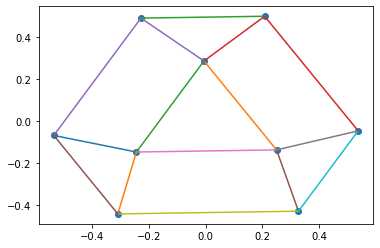

In [121]:
L = np.diag(np.sum(A,axis=1))-A
D,V = eigh(L)
Y = np.vstack((V[:,1],V[:,2])).T
plt.plot(Y[:,0],Y[:,1],'o')
for i in range(9):
    for j in range(9):
        if i<j:
            if A[i,j]==1:
                plt.plot([Y[i,0],Y[j,0]],[Y[i,1],Y[j,1]])

## Problem 2

In [122]:
# load the adjacency matrix
A = np.load('dodecahedral_graph.npy')

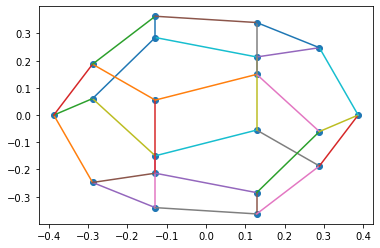

In [123]:
L = np.diag(np.sum(A,axis=1))-A
D,V = eigh(L)
Y = np.vstack((V[:,1],V[:,2])).T
plt.plot(Y[:,0],Y[:,1],'o')
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if i<j:
            if A[i,j]==1:
                plt.plot([Y[i,0],Y[j,0]],[Y[i,1],Y[j,1]])

In [124]:
L = np.diag(np.sum(A,axis=1))-A
D,V = eigh(L)
Y = np.vstack((V[:,1],V[:,2],V[:,3])).T

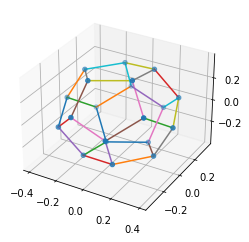

In [126]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(Y[:,0],Y[:,1],Y[:,2],'o')
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if i<j:
            if A[i,j]==1:
                plt.plot([Y[i,0],Y[j,0]],[Y[i,1],Y[j,1]],[Y[i,2],Y[j,2]])


## Problem 3

In [4]:
def kmeans(X,k):        
    from sklearn.metrics import pairwise_distances    
    # initialize iteration counter 
    it = 0    
    max_iterations=1000 
    # if it=1000, we'll stop kmeans    
    repeat=True # when centers stop moving, we'll set repeat = False
    # size of X
    m,n = X.shape
    # kmeans initialization
    centers = X[np.random.choice(m,k)]
    dist = pairwise_distances(X,centers)
    clusters = np.argmin(dist, axis=1)
    # while repeat = True and it<1000, repeat kmeans steps
    while repeat and it<max_iterations:
        # update means; 
        # if a cluster has no points associated with it, replace it with a random point
        centers = np.array([np.mean(X[clusters==i], axis=0)
        if np.sum(clusters==i)!=0
        else  X[np.random.choice(m,1)] #
        for i in range(k)])
        # update clusters
        dist = pairwise_distances(X,centers)
        new_clusters = np.argmin(dist, axis=1)
        # check if the new clusters are equal to the previous clusters
        if np.sum(clusters!=new_clusters)==0:
            repeat = False
        clusters = new_clusters
        # increment iteration counter by 1
        it += 1
            
    return clusters, centers

### Data-set 1: Eye of Sauron

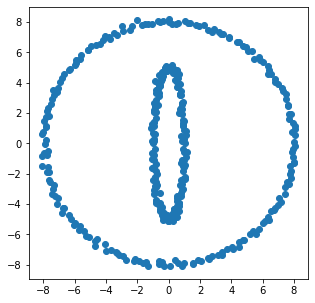

In [20]:
X = np.zeros((400,2))

# cluster 1:
theta = np.linspace(0,2*np.pi,200) 
X[0:200,0] = 8*np.sin(theta)+0.1*np.random.randn(200)
X[0:200,1] = 8*np.cos(theta)+0.1*np.random.randn(200)
# cluster 2:
X[200:400,0] = 1*np.sin(theta)+0.1*np.random.randn(200)
X[200:400,1] = 5*np.cos(theta)+0.1*np.random.randn(200)

plt.figure(figsize=(5,5))
plt.plot(X[:,0],X[:,1],'o')

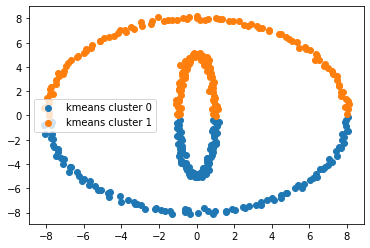

In [21]:
# run algorithm with k=2
k=2
clusters, centers = kmeans(X,k) 
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1], label = 'kmeans cluster '+str(i))
    plt.legend()

k-means doesn't work here! Let's try it on the spectral embedding of the data.

In [22]:
distances = pairwise_distances(X)
n_neighbors = 10
neighbors = np.argsort(distances,axis=1)[:,1:n_neighbors+1]
A = np.zeros((400,400))
for i in range(400):
    A[i,neighbors[i]]=1
    A[neighbors[i],i]=1

In [23]:
# Laplacian
L = np.diag(np.sum(A,axis=1))-A

#eigenvalues/eigenvectors

D,V = eigh(L)
# k eigenvectors with smallest eigenvalues
Y = V[:,0:k]

In [24]:
clusters,centers=kmeans(Y,k)

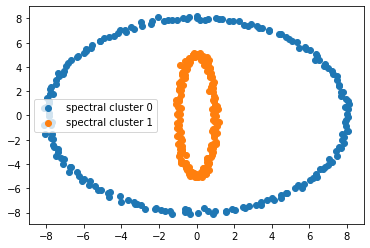

In [25]:
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1],label = 'spectral cluster '+str(i))
    plt.legend()

I think that is pretty well clustered! For the remaining datasets, we will not include the result of k-means clustering on its own (and will just include the spectral clusters).

### Data-set 2: Two-Moons dataset

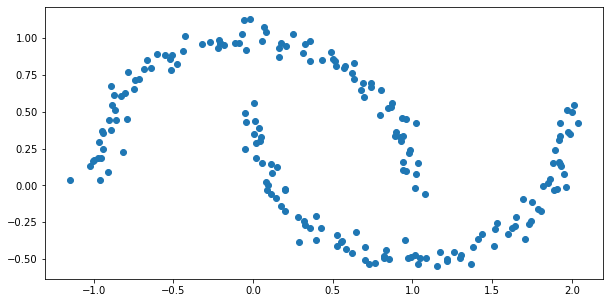

In [26]:
from sklearn.datasets import make_moons
n_points = 200
X,y = make_moons(n_samples=n_points,noise=0.05)

plt.figure(figsize=(10,5))
plt.scatter(X[:,0],X[:,1])

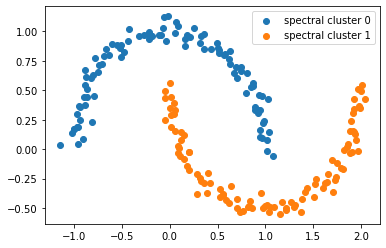

In [33]:
distances = pairwise_distances(X)
n_neighbors =5
neighbors = np.argsort(distances,axis=1)[:,1:n_neighbors+1]
A = np.zeros((200,200))
for i in range(200):
    A[i,neighbors[i]]=1
    A[neighbors[i],i]=1
    
    
# Laplacian
L = np.diag(np.sum(A,axis=1))-A

#eigenvalues/eigenvectors

D,V = eigh(L)
# k eigenvectors with smallest eigenvalues
Y = V[:,0:k]

clusters,centers=kmeans(Y,k)

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1],label = 'spectral cluster '+str(i))
    plt.legend()

### Dataset 3: Connected Circles

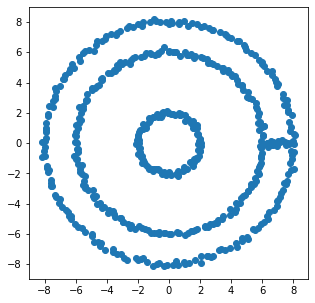

In [34]:
X = np.zeros((525,2))

# cluster 1:
theta = np.linspace(0,2*np.pi,200) 
X[0:200,0] = 8*np.sin(theta)+0.1*np.random.randn(200)
X[0:200,1] = 8*np.cos(theta)+0.1*np.random.randn(200)

X[200:400,0] = 6*np.sin(theta)+0.1*np.random.randn(200)
X[200:400,1] = 6*np.cos(theta)+0.1*np.random.randn(200)

X[400:425,0] = 6 + 2*np.random.rand(25)
X[400:425,1] = 0.1*np.random.randn(25)

# cluster 2:
theta = np.linspace(0,2*np.pi,100)
X[425:525,0] = 2*np.sin(theta)+0.1*np.random.randn(100)
X[425:525,1] = 2*np.cos(theta)+0.1*np.random.randn(100)

plt.figure(figsize=(5,5))
plt.plot(X[:,0],X[:,1],'o')

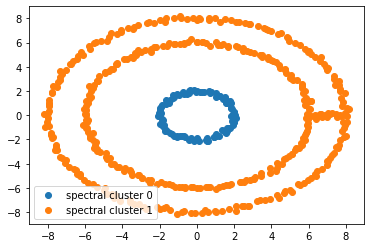

In [36]:
distances = pairwise_distances(X)
n_neighbors =5
neighbors = np.argsort(distances,axis=1)[:,1:n_neighbors+1]
A = np.zeros((525,525))
for i in range(525):
    A[i,neighbors[i]]=1
    A[neighbors[i],i]=1
    
    
# Laplacian
L = np.diag(np.sum(A,axis=1))-A

#eigenvalues/eigenvectors

D,V = eigh(L)
# k eigenvectors with smallest eigenvalues
Y = V[:,0:k]

clusters,centers=kmeans(Y,k)

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1],label = 'spectral cluster '+str(i))
    plt.legend()

### Dataset 4: Interlocking Rings (in 3D)

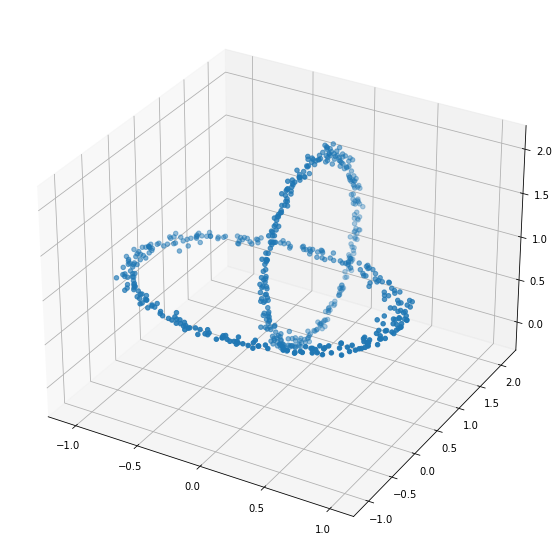

In [128]:
X = np.zeros((600,3))

# cluster 1:
theta = np.linspace(0,2*np.pi,300) 
X[0:300,0] = np.sin(theta)+0.05*np.random.randn(300)
X[0:300,1] = np.cos(theta)+0.05*np.random.randn(300)
X[0:300,2] = np.ones(300)

# cluster 2:
X[300:600,0] = np.zeros(300)
X[300:600,1] = np.sin(theta)+1+0.05*np.random.randn(300)
X[300:600,2] = np.cos(theta)+1+0.05*np.random.randn(300)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0],X[:,1],X[:,2])

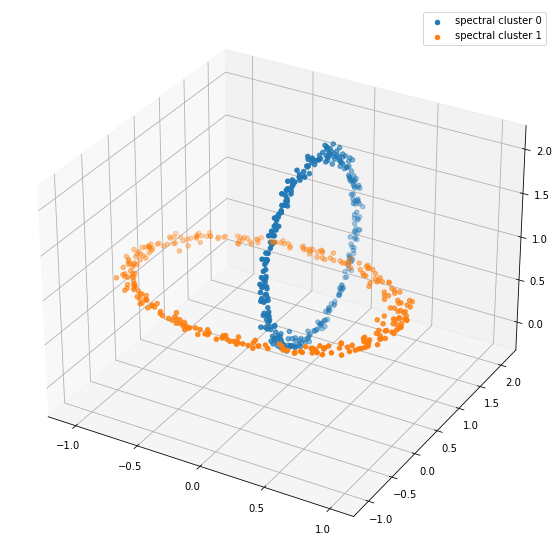

In [130]:
k=2
distances = pairwise_distances(X)
n_neighbors =5
neighbors = np.argsort(distances,axis=1)[:,1:n_neighbors+1]
A = np.zeros((600,600))
for i in range(600):
    A[i,neighbors[i]]=1
    A[neighbors[i],i]=1
    
    
# Laplacian
L = np.diag(np.sum(A,axis=1))-A

#eigenvalues/eigenvectors

D,V = eigh(L)
# k eigenvectors with smallest eigenvalues
Y = V[:,0:k]

clusters,centers=kmeans(Y,k)

    
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
for i in range(k):
    ax.scatter(X[clusters==i,0],X[clusters==i,1],X[clusters==i,2],label = 'spectral cluster '+str(i))
    plt.legend()

## Problem 4: Paul Erdos coauthors graph

In [40]:
# load Erdos adjacency matrix and Erdos'coauthors
A = np.load('Erdos_adjacency.npy')
coauthors = np.load('Erdos_coauthors.npy')

(-0.5, 327.5, 327.5, -0.5)

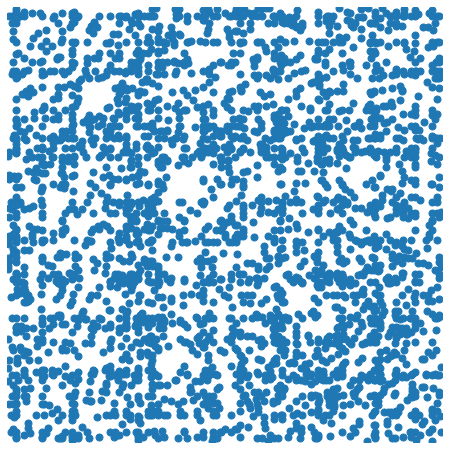

In [41]:
# visualize the adjacency matrix A
plt.figure(figsize=(8,8))
plt.spy(A,marker='o',markersize=7)
plt.axis(False)

In [77]:
# Laplacian
L = np.diag(np.sum(A,axis=0)) - A 
# eigenvectors and eigenvalues
D,V = eigh(L)

In [78]:
# clusters
c1 = np.where(V[:,1]>=0)[0] 
c2 =np.where(V[:,1]<0)[0] 
# cluster sizes
n1 = len(c1)
n2 = len(c2) 
# permutation
p = np.hstack((c1,c2)).flatten()

(-0.5, 327.5, 327.5, -0.5)

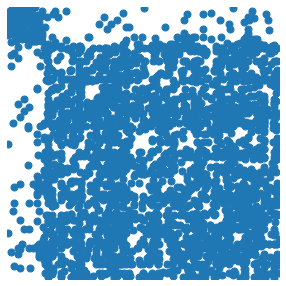

In [80]:
# permuted adjacency matrix
A_per = A[p][:,p]
plt.figure(figsize=(5,5))
plt.spy(A_per, marker='o', markersize=7)
plt.axis(False)

In [82]:
n = A.shape[0]
A1 = A_per[0:n1,0:n1] # top left block
A2 = A_per[n1:n,n1:n] # bottom right block 

L1 = np.diag(np.sum(A1,axis=0)) - A1
D1,V1 = eigh(L1)
c11 = np.where(V1[:,1]>=0) 
c12 =np.where(V1[:,1]<0)
n11 = len(c11)
n12 = len(c12)
p1 = np.hstack((c11,c12)).flatten()

L2 = np.diag(np.sum(A2,axis=0)) - A2 
D2,V2 = eigh(L2)
c21 = np.where(V2[:,1]>=0)
c22 =np.where(V2[:,1]<0) 
n21 = len(c21)
n22 = len(c22)

p2 = np.hstack((c21,c22)).flatten()

In [83]:
pp = p.copy()

pp[0:n1] = pp[0:n1][p1]
pp[n1:n] = pp[n1:n][p2]

A_per_per = A[pp][:,pp]                    

(-0.5, 327.5, 327.5, -0.5)

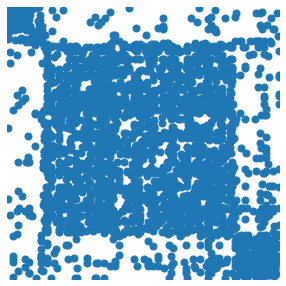

In [84]:
plt.figure(figsize=(5,5))
plt.spy(A_per_per, marker='o', markersize=7) 
plt.axis(False)

### Problem 5: Letter Clustering

In [85]:
# k-means function
def kmeans(X,k):
    
    from sklearn.metrics import pairwise_distances
    # initialize iteration counter
    it = 0

    max_iterations=1000 # if it=1000, we'll stop kmeans
    repeat=True # when centers stop moving, we'll set repeat = False
    
    # size of X
    m,n = X.shape 
    
    
    # centers initialization
    centers = np.zeros((k,n))
    # choose first center at random
    centers[0] = X[np.random.randint(m)] 
    # choose the other centers
    for center in range(1,k):
        idx = np.argmax([np.min([np.linalg.norm(X[i]-centers[j]) for j in range(center)]) for i in range(m)])
        centers[center] = X[idx]
    # initial clusters
    dist = pairwise_distances(X,centers)
    clusters = np.argmin(dist, axis=1)
 
    # while repeat = True and it<1000, repeat kmeans steps
    while repeat and it<max_iterations:
        
        # update means; # if a cluster has no points associated with it, replace it with a random point
        centers = np.array([np.mean(X[clusters==i], axis=0) 
                          if np.sum(clusters==i)!=0 
                          else  X[np.random.choice(m,1)].flatten() # 
                          for i in range(k)])
        
        # update clusters
        dist = pairwise_distances(X,centers)
        new_clusters = np.argmin(dist, axis=1)
        
        # check if the new clusters are equal to the previous clusters
        if np.sum(clusters!=new_clusters)==0: 
            repeat = False
        clusters = new_clusters
              
        # increment iteration counter by 1    
        it += 1 

    return clusters, centers

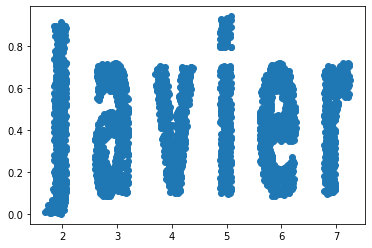

In [86]:
# load data
X = np.load('letters.npy')

# plot data
plt.scatter(X[:,0],X[:,1])

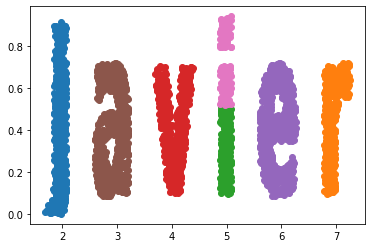

In [88]:
# run algorithm with k=2
k=7
clusters, centers = kmeans(X,k) 
for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1], label = 'kmeans cluster '+str(i))
    #plt.legend()

In [91]:
npoints = X.shape[0]

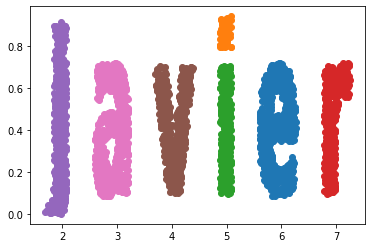

In [92]:
distances = pairwise_distances(X)
n_neighbors =5
neighbors = np.argsort(distances,axis=1)[:,1:n_neighbors+1]
A = np.zeros((npoints,npoints))
for i in range(npoints):
    A[i,neighbors[i]]=1
    A[neighbors[i],i]=1
    
    
# Laplacian
L = np.diag(np.sum(A,axis=1))-A

#eigenvalues/eigenvectors

D,V = eigh(L)
# k eigenvectors with smallest eigenvalues
Y = V[:,0:k]

clusters,centers=kmeans(Y,k)

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1],label = 'spectral cluster '+str(i))
    #plt.legend()

### Problem 6: A secret message

In [99]:
# load distance matrix
Dist = np.load('secret_message_distances.npy')
D=Dist**2

In [100]:
#Solve for G
n = D.shape[0]
G = 0.5*(np.ones((n,1)).dot(D[[0],:]) + D[:,[0]].dot(np.ones((1,n))) - D)

In [101]:
D,Q = eigh(G, subset_by_index=[n-2,n-1])
D

array([  107.35893273, 16235.25270379])

In [102]:
X = (Q*np.sqrt(D)).T
X[[0,1]] = X[[1,0]]

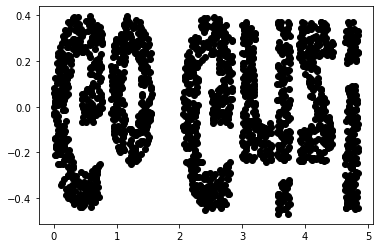

In [103]:
plt.scatter(X[0],X[1],color='black')

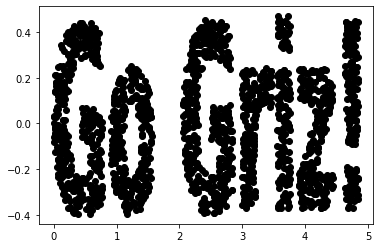

In [104]:
#I think we need one more transformation here...

flip = np.array([[1,0],[0,-1]])
X=flip.dot(X)
plt.scatter(X[0],X[1],color='black')